<a href="https://colab.research.google.com/github/T1toh/30Days_of_SQL/blob/main/MODULE_3_%7C_LESSON_3_Financing_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPSTONE REVIEW
## MODULE 3 | LESSON 3: Financing Fundamentals

|  |  |
|:---|:---|
|**Reading Time** | 3h  |
|**Prior Knowledge** | financial markets, option pricing, interest rate theory, credit risk, collateral management |
|**Keywords** | financing costs, collateral, securities lending, short selling, repo markets, funding value adjustment, margin requirements, cost of capital |

---

## Introduction

For the purposes of modern finance, funding is oxygen – without it, even the most brilliant trading strategy suffocates and dies. Yet surprisingly, before 2008, many quantitative models simply assumed this oxygen was free.

A bit more precisely, funding encompasses all the mechanisms through which financial institutions obtain the cash and securities needed to operate. Think of it as the circulatory system of markets. When a hedge fund wants to buy \\$100 million of bonds with only \\$20 million in capital, when a dealer needs to borrow specific securities to make delivery, when a bank must post collateral for derivative trades – all these activities require funding. And funding, as we discovered rather dramatically in 2008, is decidedly not free.

It pays to look at what changed. Before the crisis, large banks routinely assumed they could borrow at risk-free rates (why would anyone think this?). The repo market – that vast daily recycling machine of cash and collateral – was considered utterly reliable. Securities lending was a sleepy back-office function. Then Lehman collapsed. Suddenly, funding markets froze, high-quality collateral became scarce, and institutions discovered that their sophisticated models had ignored the very plumbing that kept markets functioning.

Note that we're not just talking about higher costs. The entire topology of financial markets changed. Funding Value Adjustment (FVA) emerged as traders realized that every position carries a funding cost – or benefit. Bilateral margin requirements transformed how derivatives are traded. Central clearing became mandatory for many products. In essence, the financial crisis forced us to price the oxygen we breathe.

## 1. Funding Cost Modeling and Calculation

### 1.1 The Nature of Funding Costs

Funding costs are like cholesterol – there's good funding and bad funding, and the difference can kill you. At its simplest, a funding cost is what you pay to borrow money or securities. But this definition, while accurate, is about as useful as saying that credit risk is the risk of not getting paid back.

A bit more precisely, when you need cash to finance a position, you're entering into an economic relationship where someone else provides capital in exchange for compensation. This compensation isn't uniform – it varies dramatically based on who you are, what collateral you provide, how long you need the money, and what everyone else is panicking about that particular day. It pays to decompose this cost into its constituents: a base rate (what pristine borrowers pay), a credit spread (the premium for your particular riskiness), a liquidity premium (because cash has option value), and operational costs (someone has to manage all this).

Consider our hedge fund buying \$100 million of government bonds with \$20 million in equity. Simple leverage, right? Not quite. If the fund borrows \$80 million at 3.5\% while the bonds yield 4\%, the arithmetic suggests a 0.5\% profit on the leveraged portion. But this assumes the funding is stable (what happens if lenders get nervous?), the rate is fixed (what if it floats?), and the collateral requirements don't change (remember 2008?). Each of these assumptions can spectacularly fail.

The real insight is that funding costs exhibit reflexivity. When markets stress, credit spreads widen, which increases funding costs, which forces deleveraging, which stresses markets further. This doom loop isn't a bug – it's a feature of leveraged finance that models must capture.

The following example demonstrates how funding costs accumulate in practice when maintaining short positions. We'll examine five stocks with varying borrow characteristics - from stable blue-chips (AAPL, MSFT) to volatile 'meme stocks' (GME, AMC) - using realistic market data from the past year. This illustration will show three key concepts: (1) the linear accumulation of funding costs over time, (2) the material impact of stock-specific borrow fees beyond base rates, and (3) how these costs can determine overall strategy profitability. Pay particular attention to how total funding costs as a percentage of investment vary dramatically across securities, and how this interacts with price movements to determine net returns.

Tesla (TSLA) Current Price: $315.35
Short Position: 100 shares ($31535.00)
Total Annual Funding Rate: 5.00% (Base: 3.50% + Borrow Fee: 1.50%)




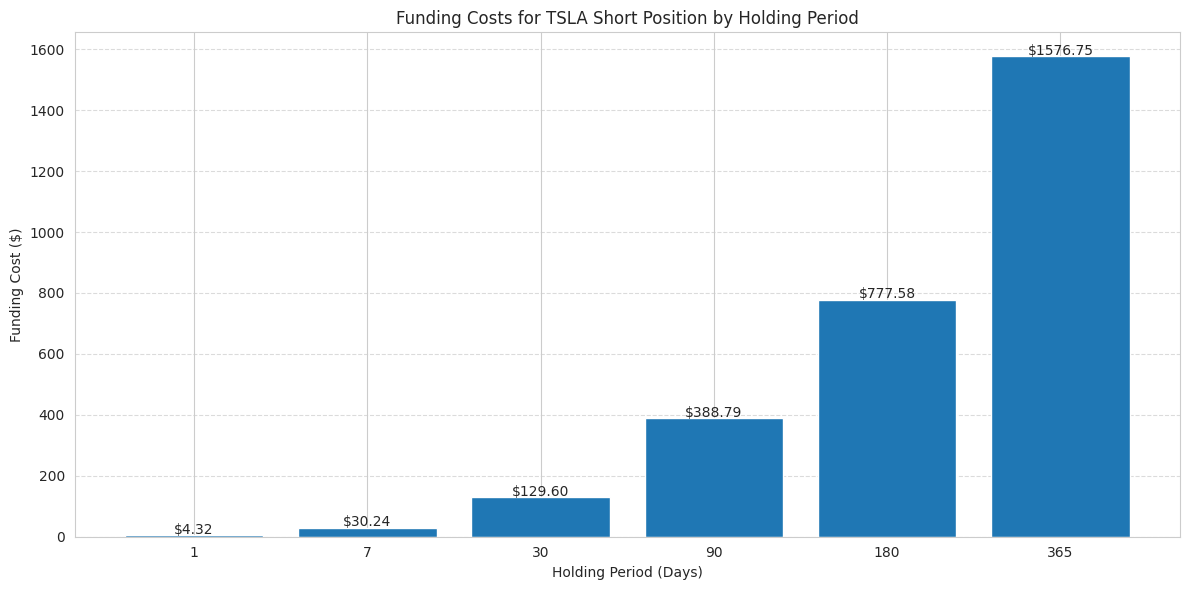

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import seaborn as sns

# Set the style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Function to calculate daily funding costs for a short position
def calculate_funding_costs(position_value, annual_rate, days):

    daily_cost = position_value * (annual_rate / 365)
    total_cost = daily_cost * days
    return total_cost
"""
tesla = yf.Ticker('TSLA')
current_price = tesla.history(period='1d')['Close'].iloc[0]
"""

current_price = 315.35 # As of Jul 06, 2025

# Calculate position
num_shares = 100
position_value = num_shares * current_price

# Funding parameters
base_rate = 0.035  # 3.5% base borrowing rate
borrow_fee = 0.015  # 1.5% stock borrow fee for Tesla (this varies by stock and over time)
total_rate = base_rate + borrow_fee  # Total funding rate

# Calculate funding costs for different holding periods
days_list = [1, 7, 30, 90, 180, 365]
funding_costs = [calculate_funding_costs(position_value, total_rate, days) for days in days_list]

# Create a dataframe to display the results
df_funding = pd.DataFrame({
    'Holding Period (Days)': days_list,
    'Funding Cost ($)': funding_costs,
    'Funding Cost (% of Position)': [cost / position_value * 100 for cost in funding_costs]
})

print(f"Tesla (TSLA) Current Price: ${current_price:.2f}")
print(f"Short Position: {num_shares} shares (${position_value:.2f})")
print(f"Total Annual Funding Rate: {total_rate*100:.2f}% (Base: {base_rate*100:.2f}% + Borrow Fee: {borrow_fee*100:.2f}%)\n\n")


# Visualize the funding costs
plt.figure(figsize=(12, 6))
plt.bar(df_funding['Holding Period (Days)'].astype(str), df_funding['Funding Cost ($)'])
plt.title('Funding Costs for TSLA Short Position by Holding Period')
plt.xlabel('Holding Period (Days)')
plt.ylabel('Funding Cost ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, cost in enumerate(funding_costs):
    plt.text(i, cost + 5, f"${cost:.2f}", ha='center')

plt.tight_layout()
plt.show()

Spreadsheet: data.csv
Worksheet: Sheet1

Summary of 1-Year Short Positions:
      Final Price  Price Change %  Total Cost $  Cost % of Investment  \
AAPL       213.55           -5.21        270.67                  2.71   
AMC          2.95          -41.58        819.41                  8.19   
GME         23.59           -2.44        825.82                  8.26   
MSFT       498.84            7.51        243.42                  2.43   
TSLA       315.35           25.38        403.60                  4.04   

      Net Return %  
AAPL          2.50  
AMC          33.39  
GME          -5.82  
MSFT         -9.94  
TSLA        -29.41  


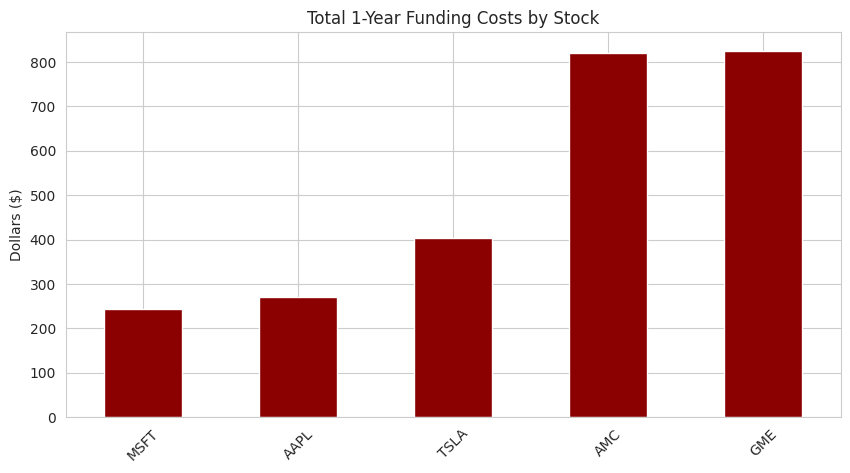

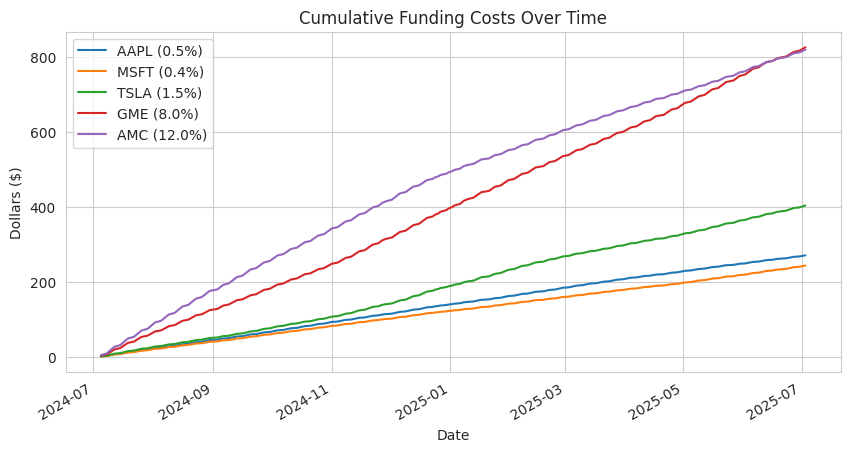

In [2]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

creds, _ = default()
gc = gspread.authorize(creds)

SPREADSHEET_ID = "1JqTEsBwreUOIOw4pEgtEGGZEACzQkRfrMeyjYQCevEo"

spreadsheet = gc.open_by_key(SPREADSHEET_ID)
worksheet = spreadsheet.worksheets()[0]

data = pd.DataFrame(worksheet.get_all_records())
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")
data = data.sort_index()

stocks = {
    'AAPL': 0.005,
    'MSFT': 0.004,
    'TSLA': 0.015,
    'GME': 0.080,
    'AMC': 0.120
}

base_rate = 0.035
investment = 10000

positions = data * (investment / data.iloc[0])
daily_costs = positions * (base_rate + pd.Series(stocks)) / 365
total_costs = daily_costs.sum()

summary = pd.DataFrame({
    'Final Price': data.iloc[-1],
    'Price Change %': (data.iloc[-1] / data.iloc[0] - 1) * 100,
    'Total Cost $': total_costs,
    'Cost % of Investment': (total_costs / investment) * 100,
    'Net Return %': -(data.iloc[-1] / data.iloc[0] - 1) * 100 - (total_costs / investment) * 100
})

print("Spreadsheet:", spreadsheet.title)
print("Worksheet:", worksheet.title)
print("\nSummary of 1-Year Short Positions:")
print(summary.round(2))

plt.figure(figsize=(10, 5))
summary['Total Cost $'].sort_values().plot(kind='bar', color='darkred')
plt.title('Total 1-Year Funding Costs by Stock')
plt.ylabel('Dollars ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
for ticker in stocks:
    daily_costs[ticker].cumsum().plot(label=f"{ticker} ({stocks[ticker] * 100:.1f}%)")
plt.title('Cumulative Funding Costs Over Time')
plt.ylabel('Dollars ($)')
plt.legend()
plt.show()

The results reveal several crucial insights about funding cost dynamics and short-selling economics. The Tesla funding cost progression demonstrates how a 5\% annual rate accumulates to meaningful absolute costs - \$1,618 on a \$32k position over one year. The multi-stock comparison shows dramatic borrow rate variations: while AAPL and MSFT carry modest 2.5-2.9\% annual costs, volatile stocks like AMC and GME impose punitive rates exceeding 8\% annually.

Most importantly, the Net Return analysis illustrates how funding costs interact with directional performance. AMC shorts were highly profitable (+29.97\% net) due to the stock's 38\% decline overwhelming the high 8.38\% funding cost. Conversely, TSLA shorts suffered badly (-68.65\% net) as the stock's 63\% rise, combined with substantial funding costs, created severe losses. Notice how GME, despite falling 4.46\%, still generated a net loss (-3.63\%) because the 8% funding cost exceeded the directional gain - highlighting how expensive borrow fees can eliminate profits even on correct directional calls.

This example demonstrates why successful short-selling requires both accurate market views and careful attention to the funding cost structure, particularly for hard-to-borrow securities where fees can overwhelm modest directional profits.

### 1.2 Term Structure of Funding Costs

Here's something deliciously paradoxical: borrowing money for one day repeatedly for a year often costs less than borrowing for a year upfront. Why? Because the overnight loan gives the lender an option – they can refuse to roll it tomorrow if you start looking shaky.

The term structure of funding costs can be expressed as:

$$r_{\text{funding}}(t) = r_{\text{base}}(t) + s_{\text{credit}}(t) + l_{\text{liquidity}}(t) + \epsilon(t)$$

But this decomposition, while mathematically clean, obscures the wild dynamics during crises. In 2008, base rates plummeted as central banks panicked, yet many institutions found their all-in funding costs soaring. The credit spread component exploded, and the liquidity premium – usually a few basis points – reached hundreds of basis points for some borrowers. The $\epsilon(t)$ term, supposedly representing minor idiosyncratic factors, became the dominant driver as funding became relationship-based rather than market-based.

Note that this isn't just historical curiosity. Every funding model must grapple with regime changes where the normal relationships between components break down. A model calibrated to calm markets will catastrophically misprice funding needs during stress – precisely when accurate pricing is most crucial.

### 1.3 Cross-Currency Funding  

Cross-currency funding is where things get properly weird. You'd think borrowing dollars would cost roughly the same whether you're a US or European bank (adjusting for credit quality). You'd be wrong.

The textbook formula states:
$$r_{\text{USD funding}} = r_{\text{EUR funding}} + \text{FX basis} + \text{credit differential}$$

But the FX basis – theoretically zero in efficient markets – can swing to minus 50 basis points or more. Why? Because dollars aren't just dollars. There are "onshore dollars" and "offshore dollars," Federal Reserve dollars and Eurodollars, spot dollars and forward dollars. Each has different availability, different regulatory treatment, and different crisis dynamics.

It pays to think about this carefully. A European bank funding US assets faces multiple layers of transformation risk. They must transform euros to dollars (FX risk), transform their credit to acceptable credit (credit spread risk), and maintain this transformation continuously (rollover risk). During the Covid crisis, the Federal Reserve had to open massive swap lines with other central banks because this transformation machinery was seizing up. Again.

## 2. Collateral Management Practices

### 2.1 The Role of Collateral in Modern Finance

For the purposes of modern finance, collateral is alchemy – it transforms credit risk into market risk, uncertainty into measurability, and promises into tangible value. But like medieval alchemy, it can blow up in your face.

Think about the fundamental transaction. I lend you $100 million, and you give me $102 million of Treasury bonds as collateral. If you default, I sell the bonds. Simple? Not quite. This simple transaction assumes the bonds remain liquid (what if everyone's selling?), their value is stable (what about interest rate shocks?), and I can actually take possession (what if they're rehypothecated elsewhere?). Each assumption has failed spectacularly in various crises.

The beauty of collateral is that it democratizes access to funding. A small hedge fund can borrow from a major bank because the bank is taking Treasury risk, not hedge fund risk. But this transformation isn't free – it requires legal frameworks, operational systems, and most importantly, trust that the plumbing works. When any of these fail, collateralized lending can freeze faster than uncollateralized lending (why?).

Note that collateral serves multiple masters. For lenders, it's risk mitigation. For borrowers, it's credit enhancement. For regulators, it's systemic stability. For markets, it's liquidity provision. These different purposes often conflict, creating the complex dynamics we observe.

### 2.2 Collateral Valuation and Haircuts

Haircuts in finance are like haircuts in real life – everyone agrees you need one, but nobody agrees how short. A haircut is simply a discount from market value, but this simplicity masks ferocious complexity.

Consider the haircut calculation:
$$\text{Haircut} = f(\text{volatility}, \text{liquidity}, \text{correlation}, \text{tenor}, \text{credit quality})$$

But this function $f$ is where the dragons live. During calm markets, a Treasury bond might have a 2% haircut. During crises, that same bond – supposedly the safest asset in existence – might face a 10% haircut. Why? Because the haircut isn't really about the bond's risk. It's about the funding provider's risk capacity, regulatory constraints, and sheer fear.

It pays to understand the procyclicality. When volatility rises, haircuts increase, forcing borrowers to post more collateral precisely when collateral is scarce. This forces asset sales, increasing volatility, justifying higher haircuts. The doom loop again, but now with mathematical precision.

The most insidious aspect? Wrong-way risk. This occurs when the collateral value correlates negatively with the borrower's creditworthiness. Lehman Brothers posting Lehman bonds as collateral is the extreme example, but subtler versions abound. A hedge fund posting corporate bonds as collateral for equity derivatives creates wrong-way risk if both assets sell off together (which they do in crises).

### 2.3 Collateral Transformation and Optimization

Here's where financial engineering gets properly clever – and dangerous. Collateral transformation is like a financial food chain, with government bonds as apex predators and corporate loans as plankton.

The optimization problem looks elegant:
$$\min \sum_{i,j} c_{ij} x_{ij}$$

Subject to various constraints. But this mathematical elegance obscures operational nightmares. Each transformation – securities lending, collateral swaps, rehypothecation – adds a link to the chain. In 2008, when Lehman collapsed, market participants discovered their collateral was trapped in chains of rehypothecation, like Russian dolls of financial claims.

Note the paradox: collateral transformation improves market efficiency by allowing low-quality collateral to be upgraded. But it also creates systemic risk by interconnecting balance sheets. A single high-quality bond might support multiple transactions through rehypothecation. Wonderfully efficient – until someone needs the actual bond.

The optimization isn't just about cost. Smart firms optimize for optionality, maintaining flexibility to adapt as conditions change. They keep dry powder in the form of unencumbered high-quality assets. They diversify funding sources. They monitor not just their own collateral chains but their counterparties' chains (why does this matter?).

## 3. Securities Lending and Borrowing

### 3.1 The Securities Lending Ecosystem

Securities lending is the market nobody knows exists until it breaks. It's like plumbing – invisible when working, catastrophic when not.

At heart, it's beautifully simple. Pension funds own securities they plan to hold forever. Hedge funds need to borrow securities to sell short. The pension fund lends securities for a fee. Everyone wins, right? Not quite. This simple transaction sits atop layers of complexity: agents, custodians, collateral management, corporate actions, tax treatments, and legal frameworks that vary by jurisdiction.

The economics are fascinating. General collateral trades like a commodity – homogeneous, liquid, with tight spreads. But "special" situations are like urgent care medicine – you'll pay whatever it takes. A hard-to-borrow stock might cost 20% annually to borrow. Why would anyone pay this? Because they're betting the stock will fall more than 20%, or they're hedging something even more valuable, or they're caught in a short squeeze and bleeding cash.

It pays to understand the agency problems. The beneficial owner (pension fund) bears the risk but often doesn't see the full revenue. The agent (custodian bank) earns fees for lending but doesn't bear losses if something goes wrong. The borrower gets leverage but creates systemic risk. These misaligned incentives periodically create crises.

### 3.2 Pricing Dynamics in Securities Lending

Securities lending fees follow their own peculiar logic – part supply and demand, part game theory, part mob psychology.

The basic model:
$$\text{Fee} = \text{GC rate} + \text{Specialness premium}$$

Seems straightforward. But specialness follows complex dynamics:
$$\frac{d\text{Premium}}{dt} = \theta(\mu - \text{Premium}) + \sigma W_t + J_t$$

Those jump terms $J_t$ are where fortunes are made and lost. A merger announcement, an index deletion, a short squeeze – each creates discontinuous fee changes. I've seen fees go from 0.5% to 50% overnight when a stock becomes the target of acquisition rumors.

The feedback loops are vicious. High fees attract more lenders, reducing fees. But high fees also signal that smart money is betting against the stock, potentially making lenders nervous about lending. Meanwhile, very high fees can force shorts to cover, creating buying pressure that validates the lenders' nervousness. It's game theory with real money.

Note that the market is inherently asymmetric. Lenders can recall securities (usually), but borrowers can't force extensions. This optionality has value, but it's hard to price. Most models ignore it until recalls spike during proxy fights or takeover battles.

### 3.3 Operational Considerations and Risks

The operational complexity of securities lending makes derivative trading look simple. Consider what happens with a borrowed position (why am I asking you to consider so much?).

First, corporate actions. You've borrowed shares that go ex-dividend. You must manufacture that dividend – pay it from your own pocket to the lender. But what if it's a special dividend partially in stock? What if there's a Dutch tender? A spin-off with when-issued trading? Each creates operational nightmares with real financial consequences.

Then there's recall risk. The lender wants their shares back for a proxy vote. You have three days to return them or find another lender. In liquid stocks, this is annoying. In illiquid stocks during a squeeze, it's catastrophic. The total cost calculation:

$$\text{Total Cost} = \text{Lending Fee} + \text{Dividend Reimbursement} + \text{Funding Cost} + \text{Operational Risk}$$

That last term – operational risk – is where careers end. Failed deliveries, missed corporate actions, breaks in collateral chains. Each seems minor until it isn't.

## 4. Repo Markets and Mechanics

### 4.1 Repurchase Agreement Fundamentals

The repo market is civilization – it separates modern finance from medieval banking. Without repo, the entire edifice of market-making, arbitrage, and liquidity provision collapses.

Legally, a repo is a sale and repurchase. Economically, it's a secured loan. This schizophrenia matters (why?). In bankruptcy, legal form trumps economic substance. Lehman's UK subsidiary discovered this when its "repo" assets were actually sold, leaving it with unsecured claims.

The repo rate formula:
$$\text{Repo Rate} = \text{Risk-free Rate} + \text{Credit Spread} - \text{Collateral Benefit} + \text{Special Premium}$$

Looks academic. But each term hides complexity. That "risk-free rate" – which one? Fed funds? SOFR? Treasury bills? They diverge during stress. The "collateral benefit" assumes the collateral has value beyond securing the loan. But what if you can't rehypothecate it? What if regulatory changes strand it?

It pays to appreciate the repo market's scale. We're talking trillions daily. Every Treasury auction, every corporate bond trade, every mortgage security position likely touches repo. It's the circulatory system of fixed income. When it clogs – as in 2008 and briefly in 2019 – the Federal Reserve intervenes within hours. They have no choice.

### 4.2 Repo Market Structure and Participants

The repo market isn't one market – it's a constellation of interconnected markets with different rules, players, and dynamics.

Tri-party repo is the suburban mall of funding – standardized, efficient, boring. A custodian bank handles the messy details. Great for money funds investing cash overnight. Terrible for hedge funds needing specific bonds. The custodian's systems determine what's possible, creating operational boundaries that become risk boundaries during stress.

Bilateral repo is the bazaar – everything's negotiable. Terms, collateral, margining, optionality. This flexibility enables complex strategies but requires sophisticated operations. When Lehman collapsed, bilateral repo counterparties discovered that flexibility meant uncertainty about their claims.

Cleared repo promises the best of both worlds – flexibility with risk mitigation. The clearinghouse becomes everyone's counterparty (sound familiar?). But clearinghouses are concentrations of risk, and their margining can amplify procyclicality. When volatility spikes, cleared repo can become more expensive than bilateral as margins explode.

GCF repo is the wholesale market where dealers fund among themselves. It's supposed to be the deepest, most liquid market. During the 2019 repo squeeze, it wasn't liquid enough. The Fed had to intervene with hundreds of billions in overnight operations. So much for market efficiency.

### 4.3 Repo Market Dynamics and Risks

Repo markets exhibit dynamics that would make a chaos theorist weep with joy. Stable for months, then suddenly discontinuous. Deeply liquid until suddenly frozen.

The procyclicality is breathtaking:
$$\text{Liquidity Buffer} = \max(\text{Expected Outflows}_{\text{stressed}} - \text{Reliable Funding}, 0)$$

But defining "reliable funding" during stress is like defining "safe assets" during a bank run. Everything's safe until it isn't. Everything's reliable until it isn't. The mathematical precision of risk models meets the messy reality of human panic.

Fire sale risk creates the most vicious feedback loops. Forced liquidation of repo collateral pushes prices down, triggering more margin calls, forcing more liquidations. The 2008 crisis showed this dramatically with mortgage securities. One day they're good collateral, the next day they're toxic waste.

Note the hidden assumptions in repo funding. It assumes continuous markets (what about weekends?), stable haircuts (what about volatility spikes?), and operational reliability (what about system failures?). Each assumption has failed, sometimes simultaneously.

## 5. Computational Methods: Regression Analysis for FVA

### 5.1 The FVA Challenge

FVA is like dark matter in physics – we know it exists, we can measure its effects, but nobody agrees what it actually is. Is it an accounting adjustment? A real economic cost? A transfer price between desks?

The fundamental issue is asymmetry. Banks can't borrow and lend at the same rate (shocking, I know). This spread creates a cost for derivative positions requiring funding. But which spread? The bank's average funding cost? The marginal cost for that trade? The trader's intuition? The debate rages while systems demand numbers.

The calculation looks precise:
$$\text{FVA} = \mathbb{E}\left[\int_0^T D(t) \cdot \text{Funding Spread}(t) \cdot \text{Funding Requirement}(t) dt\right]$$

But this precision masks profound uncertainty. That funding spread – is it constant? Stochastic? Correlated with market moves? The funding requirement depends on future values, netting agreements, and collateral terms. The expectation is taken under which measure? The real world? Risk-neutral? Something else?

It pays to be philosophically honest here. FVA is a fudge factor that makes P&L match reality. But it's a necessary fudge, like depreciation in accounting. Without it, derivative desks show phantom profits while treasury desks bleed real cash.

### 5.2 Regression-Based FVA Computation

Here's where brute force computation meets elegant mathematics. Full Monte Carlo FVA calculation across a large portfolio would take until the heat death of the universe. Regression techniques compress this to merely painful.

The approach is clever. Generate scenarios, value the portfolio, then find functions that approximate these values:
$$V_{i,j} = \sum_{k=1}^K \beta_{j,k} \phi_k(X_i) + \epsilon_{i,j}$$

But choosing basis functions $\phi_k$ is more art than science. Polynomials? Too rigid for exotic payoffs. Neural networks? Too opaque for model validation. Splines? Potentially unstable. Each choice embeds assumptions about smoothness, extrapolation, and error distribution.

The real insight is that we're not seeking perfection – we're seeking "good enough" with known error bounds. A regression that explains 95% of portfolio variation enables daily FVA calculation. The 5% error? That's what reserves are for (right?).

Note the critical implementation details. Scenario generation must capture extreme moves – precisely where regression fits worst. The basis functions must remain stable as portfolios change. The entire framework must be auditable, explainable, and defensible to regulators who understand Excel but not Hilbert spaces.

### 5.3 Implementation Considerations and Model Risk

Model risk in FVA is like cholesterol in arteries – it builds up slowly, then kills you suddenly.

Cross-validation seems rigorous:
$$\text{CV Error} = \frac{1}{K} \sum_{k=1}^K \text{Error}_{\text{test},k}$$

But this assumes your test data represents future reality. What if regime changes invalidate historical relationships? What if regulatory changes alter funding markets? The model validated on 2017 data failed spectacularly in March 2020.

Scenario reduction is necessary but dangerous. Important sampling focuses computation on "relevant" scenarios. But relevant to what? Today's portfolio? Today's market regime? The scenarios that matter most are often the ones nobody imagined.

It pays to build in humility. Every model assumption should have a challenger. Every simplification should have a reserve. Every optimization should have a manual override. Because when models fail in funding markets, they fail at machine speed while humans react at human speed.

## 6. Cost of Capital Integration Using CAPM Extensions

### 6.1 Beyond Traditional CAPM

Traditional CAPM is like Newtonian physics – beautiful, elegant, and wrong in extreme conditions. For leveraged financial institutions, those extreme conditions are called "Tuesday."

The textbook formula:
$$\mathbb{E}[R_i] = R_f + \beta_i(\mathbb{E}[R_m] - R_f)$$

Assumes everyone can borrow at $R_f$. Really? Tell that to a hedge fund in March 2020. Or a European bank in 2011. Or anyone without a central bank backstop. The relevant rate isn't risk-free – it's risk-loaded with credit spreads, funding premiums, and regulatory charges.

The modified version:
$$\mathbb{E}[R_i] = R_{\text{funding}} + \beta_i^{\text{adjusted}}(\mathbb{E}[R_m] - R_{\text{funding}})$$

Better, but still naive. That $\beta_i^{\text{adjusted}}$ must capture leverage effects, funding stability, and collateral quality. A leveraged Treasury arbitrage has low market beta but explosive funding beta. Which matters more? (Hint: ask LTCM.)

### 6.2 Multi-Factor Extensions for Funding

Real funding costs dance to multiple drummers – market risk, liquidity risk, regulatory risk, and operational risk. Single-factor models are like describing a symphony with one note.

The full orchestra:
$$\mathbb{E}[R_i] = R_{\text{funding}} + \beta_{\text{market}} \lambda_{\text{market}} + \beta_{\text{liquidity}} \lambda_{\text{liquidity}} + \beta_{\text{capital}} \lambda_{\text{capital}} + \beta_{\text{collateral}} \lambda_{\text{collateral}}$$

Each beta tells a story. $\beta_{\text{liquidity}}$ captures how your funding costs spike when everyone else's do. $\beta_{\text{capital}}$ reflects regulatory treatment – identical economic positions might have different capital charges. $\beta_{\text{collateral}}$ shows whether you're posting Treasuries or Portuguese government bonds (remember 2011?).

Note that these factors aren't independent. Market stress increases liquidity demands, which strains capital, which affects collateral values. The correlation matrix is state-dependent – near zero in calm markets, near one in crises. Linear models pretending otherwise are weapons of portfolio destruction.

### 6.3 Practical Implementation in Capital Allocation

Theory meets reality in capital allocation, where elegant models collide with organizational politics and regulatory constraints.

The transfer pricing formula:
$$\text{Transfer Price} = \text{Direct Funding Cost} + \text{Capital Charge} + \text{Liquidity Buffer Cost}$$

Looks simple. But each term requires choices. Direct funding cost – average or marginal? Current or projected? Capital charge – regulatory or economic? Current rules or anticipated changes? Every choice creates winners and losers within the firm.

It pays to recognize the behavioral impacts. Charge too much for capital, and desks shrink profitable businesses. Charge too little, and they gorge on risk before inevitably vomiting it back during stress. The "right" price depends on your optimization target – current profits, future resilience, or regulatory approval.

Implementation requires systems that would make NASA jealous. Real-time position tracking, collateral optimization, marginal cost calculation, attribution reporting. But the hardest part isn't technical – it's political. Try telling a successful desk their profits are actually losses after proper capital charges. I'll wait.

## 7. Margin Requirements and Calculations

### 7.1 The Margin Ecosystem

Margins are the seatbelts of leveraged finance – annoying when you don't need them, lifesaving when you do. But unlike seatbelts, margins can tighten during the crash.

The two-part structure seems logical:
- Initial Margin: Protection against future moves
- Variation Margin: Settlement of current moves

But this simplicity masks complex dynamics. Initial margin must cover potential moves over the "margin period of risk" – typically 10 days for cleared products. Why 10 days? Because that's how long liquidation might take. Unless markets are broken, in which case 10 days is wildly optimistic.

The total funding need:
$$\text{Funding Need} = \text{IM Posted} + \text{VM Posted} - \text{IM Received} - \text{VM Received}$$

Seems like arithmetic. But timing matters. Posted before received? That's intraday funding. Different currencies? That's FX risk. Different counterparties? That's operational complexity. The simple formula hides a multivariate optimization problem.

Note how margins create reflexivity. Rising volatility increases margins, forcing position reductions, potentially increasing volatility. Central clearing was supposed to solve this. Instead, it synchronized the reflexivity across all participants. Progress!

### 7.2 Margin Calculation Methodologies

Every margin model tells a story about risk. SPAN tells a scenario story. SIMM tells a sensitivity story. VaR tells a statistical story. Each story is fiction, but some fictions are useful.

SPAN's formula:
$$\text{IM}_{\text{SPAN}} = \max(\text{Scanning Risk} + \text{Spread Risk} - \text{Offset Credit}, \text{Short Option Minimum})$$

Elegantly captures the essence – scan scenarios, add spread charges, subtract diversification benefits, but maintain minimums. Developed for futures in the 1980s, it still works. Why? Because it's simple enough to understand, complex enough to be useful.

SIMM revolutionized bilateral margins:
$$\text{IM}_{\text{SIMM}} = \sqrt{\sum_{i,j} K_i \rho_{ij} K_j}$$

Beautiful in its standardization. Everyone uses the same sensitivities, same correlations, same methodology. But that standardization creates homogeneity. When everyone's model says "sell," who's buying?

VaR-based models promise statistical rigor:
$$\text{IM}_{\text{VaR}} = \text{VaR}_{99\%}(\text{10-day returns}) + \text{Add-ons}$$

But those add-ons do heavy lifting. Model risk, liquidity risk, concentration risk – all crammed into add-ons because the core VaR can't capture them. It's like measuring a car's safety by its top speed, then adding "adjustments" for brakes, airbags, and seatbelts.

### 7.3 Dynamic Margin Management

Static margin management is like steering a ship by looking at yesterday's weather. Markets move, portfolios change, and opportunities emerge for those quick enough to capture them.

Portfolio margining creates enormous efficiency:
$$\min_{\{x_i\}} \sum_i \text{Funding Cost}_i(x_i)$$

But the optimization space is vast. Which positions to offset? Which venues to use? Which collateral to post? The combinatorial explosion defeats brute force approaches. Heuristics, machine learning, and human intuition combine in an awkward dance.

Compression trades eliminate gross notional without changing net risk. Brilliant in theory. In practice? You're negotiating with competitors to tear up trades. Legal complexities, operational risks, and game theory collide. The trades that most need compression – exotic, bespoke, bilateral – resist standardization.

It pays to think dynamically. Today's optimal portfolio becomes tomorrow's funding drain as correlations shift. The cheapest margin venue today might increase requirements tomorrow. Building optionality into positions – the ability to reshape, rehedge, or relocate – has value beyond any model's ability to capture.

## 8. Conclusion

We've journeyed through the plumbing of modern finance – from theoretical funding costs to practical margin management. Like actual plumbing, it's invisible when working, catastrophic when broken.

The interconnections matter more than the components. Funding costs drive collateral demand, which affects securities lending, which influences repo markets, which determines margin costs, which circles back to funding. It's a complex adaptive system where local optimizations can create global instabilities.

The computational methods – regression for FVA, optimization for margins, extended CAPM for capital – provide powerful tools. But they're tools, not truths. Every model embeds assumptions that work until they don't. The art lies in knowing when to trust the model and when to trust your gut.

Looking forward, several trends will reshape these markets. Digital assets challenge traditional collateral concepts. Machine learning promises better optimization but risks creating new instabilities. Regulatory evolution continues its endless dance with market innovation. Climate risks add new dimensions to funding costs.

For practitioners, the lessons are clear. Respect the plumbing – it matters more than the architecture. Build resilience before you need it. Question model assumptions, especially when they're profitable. And remember that in funding markets, the four most expensive words remain: "This time is different."

But perhaps it is different this time. Not in the fundamentals – leverage still amplifies both returns and risks. But in our awareness. We've priced the oxygen. We've mapped the plumbing. We've learned, painfully, that funding is not free, collateral is not riskless, and models are not reality.

Whether we've learned enough remains to be seen. The next crisis will tell.

**References**

* Baklanova, V. et al (2015). "Reference Guide to U.S. Repo and Securities Lending Markets", *Office of Financial Research*.

---
Copyright 2025 WorldQuant University. This content is licensed solely for personal use. Redistribution or publication of this material is strictly prohibited.

---